# Experiment 03 — Hybrid Topology + Parameter Search for EML

Enumerate all 8 unique full-binary EML tree topologies (depth ≤ 3, Catalan shapes) and,
for each topology, run a multi-restart Adam search toward two targets:

| Target | Leaf type | Loss |
|--------|-----------|------|
| **π** (constant) | `ScalarLeaf` — single `nn.Parameter` | `(pred − π)²` |
| **sin(x)** on 50-point grid | `FnLeaf` — `nn.Linear(1,1)` | `MSE(pred(x), sin(x))` |

Phantom attractor detection: multiple independent restarts converging to the
same suboptimal loss basin.

In [1]:
import math, json, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e", "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e", "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4", "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62", "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,       "lines.linewidth":  1.8,
    "font.family":      "monospace","font.size":        10,
})
ORANGE = "#e8a020"; BLUE = "#6ab0f5"; GREEN = "#4ade80"
RED    = "#f87171"; MUTED = "#4a4d62"

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}  |  device: {device}")

torch 2.11.0+cpu  |  device: cpu


In [2]:
# ── Differentiable EML building blocks ───────────────────────────────────────
#
# ScalarLeaf  — single nn.Parameter; for constant-target search (π)
# FnLeaf      — nn.Linear(1,1);      for function-target search (sin x)
# EMLNode     — eml(left, right) = exp(left) − ln(right)
#
# Mirrors monogate.network._Leaf / _LinearLeaf / _Node exactly,
# but self-contained so the notebook has no private imports.

class ScalarLeaf(nn.Module):
    """Trainable scalar leaf — one nn.Parameter."""
    def __init__(self, init: float = 1.0):
        super().__init__()
        self.val = nn.Parameter(torch.tensor(float(init), device=device))

    def forward(self, _x=None):
        return self.val

    def formula(self, names=None):
        return f"{self.val.item():.5g}"


class FnLeaf(nn.Module):
    """
    Linear leaf — nn.Linear(in_features, 1).
    Init: near-zero weights, bias=1 → each leaf starts ≈ 1 (EML-safe region).
    forward(x) takes (batch, in_features) and returns (batch,).
    """
    def __init__(self, in_features: int = 1):
        super().__init__()
        self.linear = nn.Linear(in_features, 1, device=device)
        nn.init.uniform_(self.linear.weight, -0.05, 0.05)
        nn.init.ones_(self.linear.bias)

    def forward(self, x):
        return self.linear(x).squeeze(-1)   # (batch,)

    def formula(self, names=None):
        w      = self.linear.weight.data.squeeze(0)
        b      = self.linear.bias.data.item()
        labels = names or [f"x{i}" for i in range(w.shape[0])]
        parts  = [f"{w[i].item():.4g}·{labels[i]}" for i in range(w.shape[0])
                  if abs(w[i].item()) > 1e-4]
        if abs(b) > 1e-4:
            parts.append(f"{b:.4g}")
        return "(" + ("+".join(parts) if parts else "0") + ")"


class EMLNode(nn.Module):
    """eml(left, right) = exp(left) − ln(right).  softplus keeps rv > 0."""
    def __init__(self, left: nn.Module, right: nn.Module):
        super().__init__()
        self.left  = left
        self.right = right

    def forward(self, x=None):
        lv = self.left(x)
        rv = F.softplus(self.right(x))   # rv > 0 → ln domain safe throughout training
        return torch.exp(lv) - torch.log(rv)

    def formula(self, names=None):
        return f"eml({self.left.formula(names)}, {self.right.formula(names)})"


print("EML building blocks defined.")

EML building blocks defined.


In [3]:
# ── Topology enumeration ──────────────────────────────────────────────────────
#
# All 8 unique full-binary tree shapes for depth 1–3.
# depth 1: 1 shape   (C₁ = 1)
# depth 2: 2 shapes  (C₂ = 2)
# depth 3: 5 shapes  (C₃ = 5)   ← all Catalan structures
#
# Encoding: 'L' = leaf,  ('N', left, right) = internal node

SHAPES = [
    # depth 1
    ('N', 'L', 'L'),
    # depth 2
    ('N', ('N', 'L', 'L'), 'L'),
    ('N', 'L', ('N', 'L', 'L')),
    # depth 3  (all 5 Catalan shapes)
    ('N', ('N', ('N', 'L', 'L'), 'L'), 'L'),
    ('N', ('N', 'L', ('N', 'L', 'L')), 'L'),
    ('N', ('N', 'L', 'L'), ('N', 'L', 'L')),
    ('N', 'L', ('N', ('N', 'L', 'L'), 'L')),
    ('N', 'L', ('N', 'L', ('N', 'L', 'L'))),
]

def _leaves(s):  return 1 if s == 'L' else _leaves(s[1]) + _leaves(s[2])
def _depth(s):   return 0 if s == 'L' else 1 + max(_depth(s[1]), _depth(s[2]))
def _desc(s):    return '1' if s == 'L' else f"eml({_desc(s[1])},{_desc(s[2])})"

def build(shape, leaf_fn):
    """Recursively construct a fresh EML tree from a shape spec + leaf factory."""
    if shape == 'L':
        return leaf_fn()
    return EMLNode(build(shape[1], leaf_fn), build(shape[2], leaf_fn))


print(f"{'ID':<4} {'Depth':<7} {'Leaves':<8} Topology")
print("─" * 58)
for i, s in enumerate(SHAPES):
    print(f"{i:<4} {_depth(s):<7} {_leaves(s):<8} {_desc(s)}")

ID   Depth   Leaves   Topology
──────────────────────────────────────────────────────────
0    1       2        eml(1,1)
1    2       3        eml(eml(1,1),1)
2    2       3        eml(1,eml(1,1))
3    3       4        eml(eml(eml(1,1),1),1)
4    3       4        eml(eml(1,eml(1,1)),1)
5    2       4        eml(eml(1,1),eml(1,1))
6    3       4        eml(1,eml(eml(1,1),1))
7    3       4        eml(1,eml(1,eml(1,1)))


In [4]:
# ── Hybrid search: constant target (π) ───────────────────────────────────────
#
# Each leaf is a ScalarLeaf (single nn.Parameter).
# Loss = (model() − π)²   — scalar, no input needed.

def search_pi(shapes, num_restarts=5, steps=1500, lr=0.01):
    target  = torch.tensor(math.pi, device=device)
    records = []

    for shape in shapes:
        r_losses = []
        best_loss, best_model = float('inf'), None

        for r in range(num_restarts):
            torch.manual_seed(r * 1000 + 7)

            # Random init near 1.0 (EML-safe start) — each restart gets fresh values
            def scalar_leaf():
                return ScalarLeaf(1.0 + torch.randn(1).item() * 0.4)

            model = build(shape, scalar_leaf)
            opt   = torch.optim.Adam(model.parameters(), lr=lr)
            last  = float('inf')

            for _ in range(steps):
                opt.zero_grad()
                try:
                    pred = model()
                    loss = (pred - target).pow(2)
                    if not torch.isfinite(loss): break
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    last = loss.item()
                except Exception: break

            r_losses.append(last)
            if last < best_loss:
                best_loss, best_model = last, model

        # Phantom: all restarts converge to the same suboptimal basin
        spread   = max(r_losses) - min(r_losses)
        is_ph    = (min(r_losses) > 1e-4) and (spread < 5e-4)

        records.append({
            'shape':     shape,
            'depth':     _depth(shape),
            'leaves':    _leaves(shape),
            'nodes':     _leaves(shape) - 1,
            'desc':      _desc(shape),
            'loss':      best_loss,
            'leaf_vals': [round(p.item(), 6) for p in best_model.parameters()] if best_model else [],
            'formula':   best_model.formula() if best_model else 'N/A',
            'phantom':   is_ph,
        })

    records.sort(key=lambda r: r['loss'])
    return records


print("Searching π  (8 topologies × 5 restarts × 1500 steps) ...")
t0 = time.perf_counter()
pi_results = search_pi(SHAPES)
print(f"Done in {time.perf_counter()-t0:.1f}s\n")

print(f"{'#':<4} {'D':<4} {'L':<4} {'Loss':<14} {'Phantom':<11} Formula")
print("─" * 75)
for i, r in enumerate(pi_results):
    ph = '⚠ PHANTOM' if r['phantom'] else ''
    print(f"{i+1:<4} {r['depth']:<4} {r['leaves']:<4} {r['loss']:<14.4e} {ph:<11} {r['formula'][:42]}")

Searching π  (8 topologies × 5 restarts × 1500 steps) ...


Done in 62.0s

#    D    L    Loss           Phantom     Formula
───────────────────────────────────────────────────────────────────────────
1    1    2    0.0000e+00                 eml(1.2315, 1.0218)
2    2    3    0.0000e+00                 eml(eml(0.51056, 1.2145), 1.33)
3    2    3    0.0000e+00                 eml(1.3429, eml(0.91815, 1.7805))
4    3    4    0.0000e+00                 eml(eml(eml(0.35757, 1.9202), 2.0401), 1.2
5    3    4    0.0000e+00                 eml(eml(0.88189, eml(1.3704, 1.3201)), 0.5
6    2    4    0.0000e+00                 eml(eml(0.59786, 1.112), eml(1.1912, 0.175
7    3    4    0.0000e+00                 eml(1.5144, eml(eml(0.79258, 1.9217), 1.17
8    3    4    0.0000e+00                 eml(1.2362, eml(1.0157, eml(1.6745, 0.2554


In [5]:
# ── Hybrid search: function target sin(x) ────────────────────────────────────
#
# Each leaf is a FnLeaf (nn.Linear(1,1)) — takes x as input.
# Loss = MSE(model(x_grid), sin(x_grid))  over the full 50-point grid.
#
# This is the key fix vs. the original draft which optimised against
# scalar mean(sin(x)) — a constant, not a function.

x_grid     = torch.linspace(0, 2 * math.pi, 50, device=device)  # (50,)
sin_target = torch.sin(x_grid)                                    # (50,)
x_in       = x_grid.unsqueeze(1)                                  # (50, 1) — batch input


def search_sin(shapes, num_restarts=5, steps=2000, lr=0.01):
    records = []
    global_best_loss, global_best_model = float('inf'), None

    for shape in shapes:
        r_losses = []
        best_loss, best_model = float('inf'), None

        for r in range(num_restarts):
            torch.manual_seed(r * 1000 + 13)
            model = build(shape, lambda: FnLeaf(in_features=1))
            opt   = torch.optim.Adam(model.parameters(), lr=lr)
            last  = float('inf')

            for _ in range(steps):
                opt.zero_grad()
                try:
                    pred = model(x_in)                 # (50,) — full grid forward pass
                    loss = F.mse_loss(pred, sin_target) # MSE over all 50 points
                    if not torch.isfinite(loss): break
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    last = loss.item()
                except Exception: break

            r_losses.append(last)
            if last < best_loss:
                best_loss, best_model = last, model

        spread = max(r_losses) - min(r_losses)
        is_ph  = (min(r_losses) > 1e-3) and (spread < 1e-3)

        records.append({
            'shape':   shape,
            'depth':   _depth(shape),
            'leaves':  _leaves(shape),
            'nodes':   _leaves(shape) - 1,
            'desc':    _desc(shape),
            'loss':    best_loss,
            'formula': best_model.formula(['x']) if best_model else 'N/A',
            'phantom': is_ph,
            '_model':  best_model,    # keep reference for plotting
        })

        if best_loss < global_best_loss:
            global_best_loss, global_best_model = best_loss, best_model

    records.sort(key=lambda r: r['loss'])
    return records, global_best_model


print("Searching sin(x) on 50-point grid [0, 2π]  (8 topologies × 5 restarts × 2000 steps) ...")
t0 = time.perf_counter()
sin_results, best_sin_model = search_sin(SHAPES)
print(f"Done in {time.perf_counter()-t0:.1f}s\n")

print(f"{'#':<4} {'D':<4} {'L':<4} {'MSE':<14} {'Phantom':<11} Formula")
print("─" * 82)
for i, r in enumerate(sin_results):
    ph = '⚠ PHANTOM' if r['phantom'] else ''
    print(f"{i+1:<4} {r['depth']:<4} {r['leaves']:<4} {r['loss']:<14.4e} {ph:<11} {r['formula'][:46]}")

Searching sin(x) on 50-point grid [0, 2π]  (8 topologies × 5 restarts × 2000 steps) ...


Done in 127.6s

#    D    L    MSE            Phantom     Formula
──────────────────────────────────────────────────────────────────────────────────
1    3    4    8.0883e-04                 eml((0.5531·x+-2.068), eml((0.687·x+-0.1015), 
2    2    3    8.7250e-04                 eml((0.5454·x+-1.849), eml((1.061·x+-1.881), (
3    2    4    2.8600e-03                 eml(eml((0.2164·x+-0.1355), (0.6478·x+2.252)),
4    3    4    7.5043e-03     ⚠ PHANTOM   eml(eml((-0.5127·x+0.08771), eml((0.8364·x+-2.
5    3    4    1.3076e-01                 eml((-0.3551·x+1.155), eml(eml((0.02034·x+0.62
6    1    2    2.1638e-01     ⚠ PHANTOM   eml((-0.1188·x+0.6301), (0.4612·x+2.365))
7    3    4    2.1793e-01                 eml(eml(eml((-0.01071·x+0.1436), (0.03616·x+1.
8    2    3    2.1805e-01     ⚠ PHANTOM   eml(eml((-0.03487·x+0.3315), (0.1174·x+1.665))


Saved → D:\monogate\python\notebooks\experiment_03_results.png


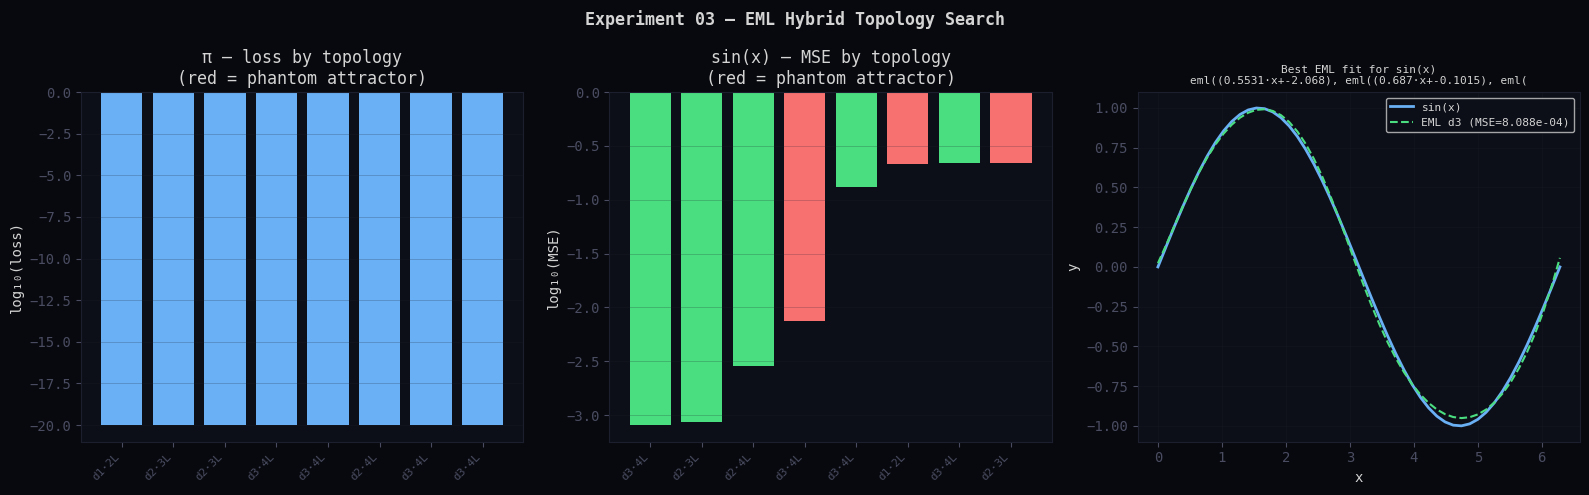

In [6]:
# ── Plot: three-panel figure ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Experiment 03 — EML Hybrid Topology Search',
             color='#d4d4d4', fontsize=12, fontweight='bold')

# Panel A: π loss by topology (sorted best→worst)
ax      = axes[0]
labels  = [f"d{r['depth']}·{r['leaves']}L" for r in pi_results]
log_l   = np.log10(np.array([r['loss'] for r in pi_results]) + 1e-20)
colors  = [RED if r['phantom'] else BLUE for r in pi_results]
ax.bar(range(len(labels)), log_l, color=colors)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('log₁₀(loss)')
ax.set_title('π — loss by topology\n(red = phantom attractor)', color='#d4d4d4')
ax.grid(True, axis='y', alpha=0.3)

# Panel B: sin(x) MSE by topology (sorted best→worst)
ax      = axes[1]
labels2 = [f"d{r['depth']}·{r['leaves']}L" for r in sin_results]
log_m   = np.log10(np.array([r['loss'] for r in sin_results]) + 1e-20)
colors2 = [RED if r['phantom'] else GREEN for r in sin_results]
ax.bar(range(len(labels2)), log_m, color=colors2)
ax.set_xticks(range(len(labels2)))
ax.set_xticklabels(labels2, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('log₁₀(MSE)')
ax.set_title('sin(x) — MSE by topology\n(red = phantom attractor)', color='#d4d4d4')
ax.grid(True, axis='y', alpha=0.3)

# Panel C: best sin(x) EML fit vs ground truth
ax      = axes[2]
x_np    = x_grid.cpu().numpy()
y_true  = sin_target.cpu().numpy()
with torch.no_grad():
    y_pred = best_sin_model(x_in).cpu().numpy()
best_r  = sin_results[0]
ax.plot(x_np, y_true, color=BLUE,  linewidth=2,   label='sin(x)')
ax.plot(x_np, y_pred, color=GREEN, linewidth=1.5,
        linestyle='--', label=f"EML d{best_r['depth']} (MSE={best_r['loss']:.3e})")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f"Best EML fit for sin(x)\n{best_r['formula'][:50]}",
             color='#d4d4d4', fontsize=8)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_dir  = Path('D:/monogate/python/notebooks')
out_path = out_dir / 'experiment_03_results.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

In [7]:
# ── JSON export + printed summary ─────────────────────────────────────────────

def _serialise(r):
    """Strip non-serialisable fields and convert tuples to strings."""
    return {k: (str(v) if k == 'shape' else v)
            for k, v in r.items() if k != '_model'}

out_dir   = Path('D:/monogate/python/notebooks')
json_path = out_dir / 'experiment_03_results.json'
json_path.write_text(json.dumps({
    'pi':  [_serialise(r) for r in pi_results],
    'sin': [_serialise(r) for r in sin_results],
}, indent=2))
print(f"Saved → {json_path}")

# ── Summary ───────────────────────────────────────────────────────────────────
bp = pi_results[0]
bs = sin_results[0]

print("\n" + "═" * 62)
print("EXPERIMENT 03 — RESULTS SUMMARY")
print("═" * 62)

print(f"\n  Best π topology:")
print(f"    Depth   : {bp['depth']}")
print(f"    Nodes   : {bp['nodes']}")
print(f"    Loss    : {bp['loss']:.4e}")
print(f"    Formula : {bp['formula']}")
print(f"    Leaves  : {bp['leaf_vals']}")
print(f"    Phantom : {bp['phantom']}")

print(f"\n  Best sin(x) topology:")
print(f"    Depth   : {bs['depth']}")
print(f"    Nodes   : {bs['nodes']}")
print(f"    MSE     : {bs['loss']:.4e}")
print(f"    Formula : {bs['formula']}")
print(f"    Phantom : {bs['phantom']}")

n_ph_pi  = sum(1 for r in pi_results  if r['phantom'])
n_ph_sin = sum(1 for r in sin_results if r['phantom'])
print(f"\n  Phantom attractors:")
print(f"    π:      {n_ph_pi} / {len(pi_results)} topologies")
print(f"    sin(x): {n_ph_sin} / {len(sin_results)} topologies")

print("\n  🎉 experiment_03 complete!")

Saved → D:\monogate\python\notebooks\experiment_03_results.json

══════════════════════════════════════════════════════════════
EXPERIMENT 03 — RESULTS SUMMARY
══════════════════════════════════════════════════════════════

  Best π topology:
    Depth   : 1
    Nodes   : 1
    Loss    : 0.0000e+00
    Formula : eml(1.2315, 1.0218)
    Leaves  : [1.231454, 1.021807]
    Phantom : False

  Best sin(x) topology:
    Depth   : 3
    Nodes   : 3
    MSE     : 8.0883e-04
    Formula : eml((0.5531·x+-2.068), eml((0.687·x+-0.1015), eml((1.818·x+0.09246), (-2.363·x+0.9304))))
    Phantom : False

  Phantom attractors:
    π:      0 / 8 topologies
    sin(x): 3 / 8 topologies

  🎉 experiment_03 complete!
